In [ ]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import napari
from tkinter import filedialog as fd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
from nilearn import image
from nilearn import plotting
from scipy.ndimage import gaussian_filter
import math
import matplotlib.patches as patches
from fsl.wrappers import bet, fast


Data pre-processing pipeline

In [ ]:

# dataset_num_list = [105, 127, 128, 130]
# for dataset_num in dataset_num_list:
#     folder = './Data/ixi/T1/' + str(dataset_num) + '/hf/'
#     img = nib.load(folder + 'raw.nii.gz')
#     reoriented_img = nib.as_closest_canonical(img)
#     nib.save(reoriented_img, folder + 'raw.nii.gz')
#     print("Original Image: ", img.get_fdata().shape, "Reoriented Image: ", reoriented_img.get_fdata().shape)

#     bet(folder+'raw.nii.gz', folder+'brain.nii.gz', mask=True, fracintensity=0.5)
#     print("Brain extraction completed....")

#     fast(folder+'brain.nii.gz', out= folder+'fast', g= False, b=True, B=True, n_classes=3, t=1)
#     print("Segmentation completed....")


Loading all files

In [77]:
def mask(seg, val):
    #To extract individual tissue from segmentation nib file
    binary_mask = np.where(seg == val, 1, 0) # Integer Mask
    return binary_mask

#dataset 1
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain.nii.gz")
seg = nib.load(seg_loc).get_fdata()
"""

#dataset 2
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
"""


#IXI sample 102
'''
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/ixi/T1/102/hf/fast_pveseg.nii.gz"
csf_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/ixi/T1/102/hf/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
'''

# Validation Data - sub_0011


# folder = './Data/validation_data/sub_0035/ulf' 
dataset_num = 130
folder = './Data/ixi/T1/' + str(dataset_num) + '/hf/'
seg_loc = folder + "/fast_seg.nii.gz"
csf_nib = nib.load(folder + "/fast_pve_0.nii.gz")
gm_nib = nib.load(folder + "/fast_pve_1.nii.gz")
wm_nib = nib.load(folder + "/fast_pve_2.nii.gz")
img_nib = nib.load(folder + "/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
noise = nib.load(folder + "/raw.nii.gz")




#Extracting tissues
csf_masked = mask(seg,1)
gm_masked = mask(seg,2)
wm_masked = mask(seg,3)

csf = csf_masked  * img_nib.get_fdata() #* csf_nib.get_fdata()
gm = gm_masked  * img_nib.get_fdata() #* gm_nib.get_fdata()
wm = wm_masked  * img_nib.get_fdata() #* wm_nib.get_fdata()
hf = hf_img = csf + gm + wm

In [ ]:
csf.shape

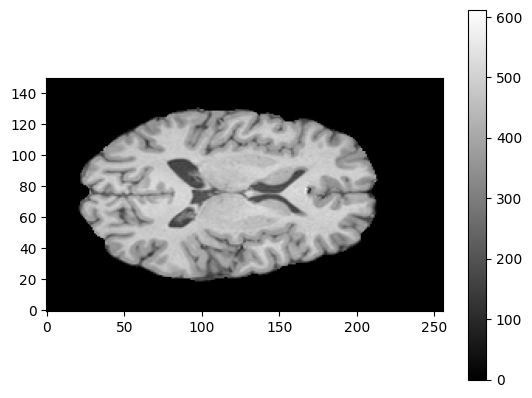

In [79]:
%matplotlib inline
slice_num = 160
plt.imshow(img_nib.get_fdata()[:,:,slice_num],cmap='gray')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

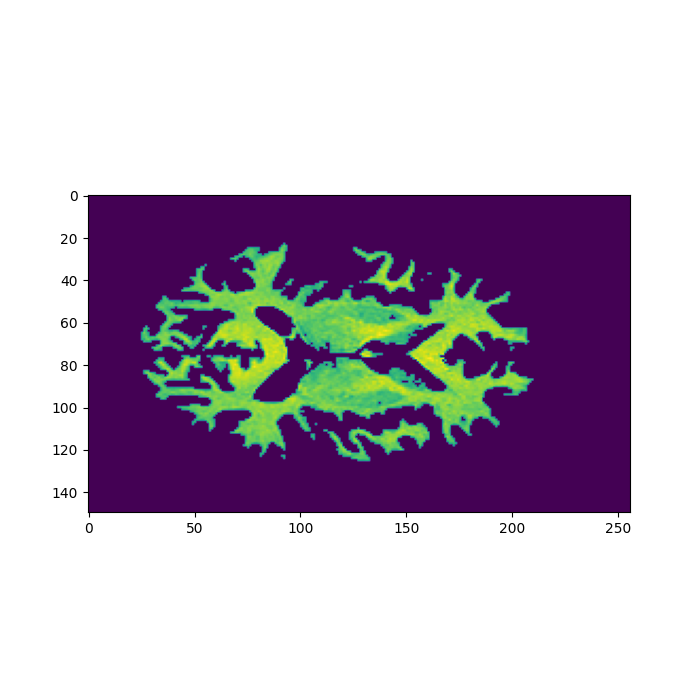

In [82]:
%matplotlib ipympl
# %matplotlib inline

import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from mpl_interactions import image_segmenter


im = Image.fromarray((wm*img_nib.get_fdata())[:,:,slice_num])
segmenter = image_segmenter(im, mask_colors="red", mask_alpha=0.99, figsize=(7, 7))
display(segmenter,colormaps='gray',colorbar=segmenter)



In [ ]:
#dataset = 1 #csf (119,82) (128,82) -> (119,85) (128,85) #gm (123, 77) (126, 79) -> (133,70) (135, 74)
#dataset = 2 #wm(135,106) (142,106) -> (135,103) (142, 103) #gm (43, 50) (47,50) -> (43, 46) (47, 46), #csf (64, 101) (83,101) -> (64,98) (83,98)

In [83]:
wm_x, wm_y, wm_w, wm_h = [112, 86, 10, 8]
gm_x, gm_y, gm_w, gm_h = [112, 32, 5, 3]
csf_x, csf_y, csf_w, csf_h = [85, 90, 6, 3]

# bg_x, bg_y, bg_w, bg_h = (9, 90, 5, 5)

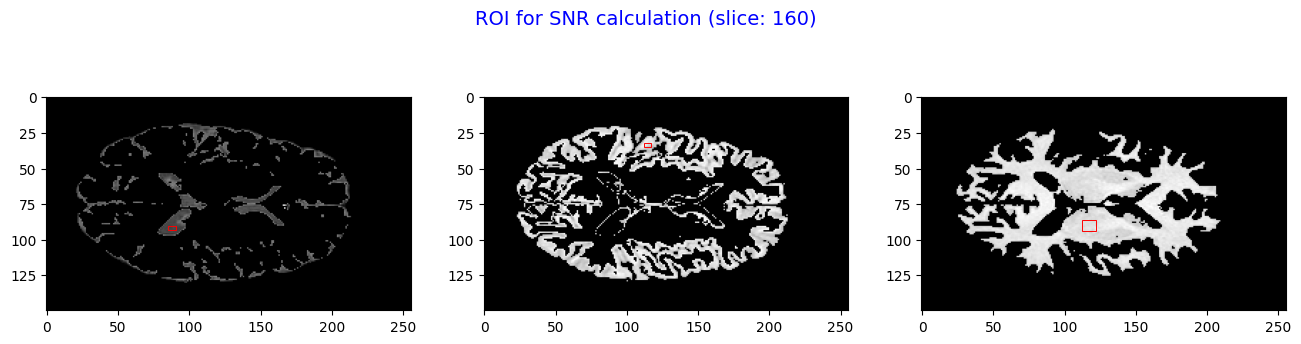

In [85]:
%matplotlib inline
# %matplotlib ipympl

fig_roi, axs = plt.subplots(1, 3, figsize=(16, 4))
im1 = axs[0].imshow((csf)[:,:,slice_num],cmap='gray')# ,vmax = 1000)
im2 = axs[1].imshow((gm)[:,:,slice_num],cmap='gray')#,vmax = 800)
im3 = axs[2].imshow((wm)[:,:,slice_num],cmap='gray')#,vmax = 600)


# rect3 = patches.Rectangle((55, 69), 5, 3, linewidth=1, edgecolor='r', facecolor='none') #ms 
rect0 = patches.Rectangle((csf_x, csf_y), csf_w, csf_h, linewidth=0.7, edgecolor='r', facecolor='none') #csf 
rect1 = patches.Rectangle((gm_x, gm_y), gm_w, gm_h, linewidth=0.7, edgecolor='r', facecolor='none') #gm 
rect2 = patches.Rectangle((wm_x, wm_y), wm_w, wm_h, linewidth=0.7, edgecolor='r', facecolor='none') #wm

axs[0].add_patch(rect0)
axs[1].add_patch(rect1)
axs[2].add_patch(rect2)
# axs[3].add_patch(rect3)



fig_roi.suptitle('ROI for SNR calculation'+ ' (slice: ' + str(slice_num) + ')', fontsize=14,color='blue')
plt.show()

In [ ]:
#dataset = 1
# csf[82:86,119:128,95]
# gm[76:80, 123:128,95]
# wm[99:109,145:155,95]
# print(wm[99:109,145:155,95].mean(), gm[76:80, 123:128,95].mean(), csf[82:86,119:128,95].mean())

#dataset = 2
# print((wm)[105:110, 132:142, 95].mean(), (gm)[45:48,43:48,95].mean(), (csf)[96:101,70:80,95].mean())

Check if there are any pixels where signal intensity = 0

In [86]:
#val data
print("WM: ", wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num])
print("GM: ", gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num])
print("CSF: ", csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num])

# print(csf[104:114, 125:133, slice_num])
print("Mean signals of csf: ", csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num].mean(), "gm: ", gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num].mean(), "wm: ", wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num].mean())



WM:  [[461.91366577 457.89529419 456.40707397 459.08770752 468.42669678
  472.02734375 456.69454956 448.05737305 458.47277832 455.76211548]
 [473.54318237 462.8711853  461.40612793 465.78234863 470.19195557
  463.89273071 459.32977295 463.93743896 456.21728516 446.0982666 ]
 [471.99227905 473.84347534 473.22625732 467.64831543 467.11474609
  471.63290405 468.74649048 458.47000122 455.73696899 462.18756104]
 [473.09945679 478.32885742 469.38513184 474.67901611 467.50561523
  460.41455078 465.05200195 458.94061279 467.86694336 473.53295898]
 [481.91021729 469.56515503 458.96496582 467.66775513 462.18795776
  459.28991699 472.32147217 474.56054688 470.20211792 466.74835205]
 [474.08087158 457.53561401 449.47027588 468.31774902 477.11077881
  475.0647583  472.25714111 473.70236206 480.2387085  482.65716553]
 [470.56695557 466.65924072 475.44815063 483.42160034 484.69503784
  491.92086792 489.12808228 478.003479   475.35653687 483.69259644]
 [464.67028809 475.18743896 467.95861816 469.24386

In [87]:

#taking mean of only those samples which are 90% probabilistic


wm_roi_pixels = img_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num][wm_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num]>0.9]
gm_roi_pixels = img_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num][gm_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num]>0.9]
csf_roi_pixels = img_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num][csf_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num]>0.9]

print("Mean signals of csf: ",csf_roi_pixels.mean(), "gm: ", gm_roi_pixels.mean(), "wm: ", wm_roi_pixels.mean())


Mean signals of csf:  170.62411838107639 gm:  388.29710693359374 wm:  468.33434638977053


Noise
- Loading raw image and computing BG nosie

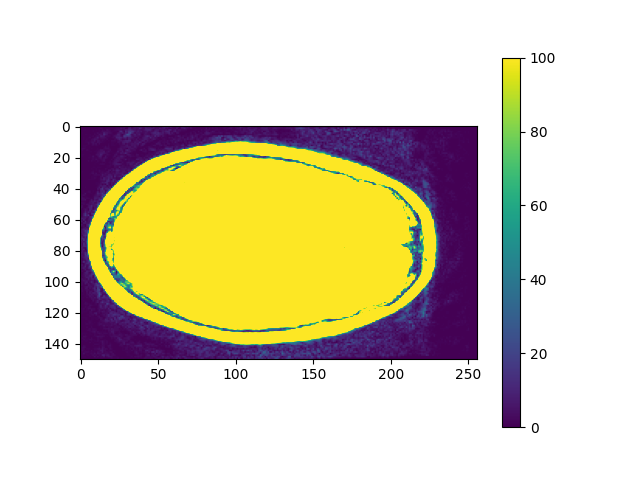

In [88]:
%matplotlib ipympl
# %matplotlib inline


plt.imshow(noise.get_fdata()[:,:,slice_num], vmax = 100)
# plt.imshow(noise.get_fdata()[:,174 ,:])
# plt.imshow(img_nib.get_fdata()[: ,:,slice_num])
plt.colorbar()
plt.show()


In [89]:

# bg_x, bg_y, bg_w, bg_h = (8, 88, 10, 10)
bg_x, bg_y, bg_w, bg_h = (174, 137, 10, 5)

std_bg = noise.get_fdata()[:,:,slice_num][bg_y:bg_y+bg_h,bg_x:bg_x+bg_w, ] #region-1 #Validation data
print(std_bg)
std_bg = std_bg.std()
print(std_bg)
# std_bg = noise.get_fdata()[:,:,slice_num][28:42, 20:30, ].std() #region-1 #Validation data
# print(std_bg)
# noise.get_fdata()[:,163,:][50:60,124:138, ].std() #region-2


[[13. 23. 14. 11. 13.  8. 11. 18. 15.  9.]
 [18. 19.  9. 16. 19. 11. 13. 16.  5.  4.]
 [ 1. 15. 24. 16. 13. 16. 18.  5.  4.  9.]
 [17. 14. 11. 11. 14.  8. 12. 17.  5. 13.]
 [ 6.  6.  7.  5. 14. 10.  5.  5.  6.  8.]]
5.2459508194416005


In [ ]:
'''
def show_slices(slices):
   """ Function to display row of image slices """
   fig, axes = plt.subplots(1, len(slices))
   for i, slice in enumerate(slices):
       axes[i].imshow(slice, cmap="gray", origin="lower")

epi_img_data = noise.get_fdata()
slice_0 = epi_img_data[198, :, :]
slice_1 = epi_img_data[:, 170, :]
slice_2 = epi_img_data[:, :, 75]
show_slices([slice_0, slice_1, slice_2])
'''

In [90]:
rayleigh_correction = 1.53
SNR_WM =  wm_roi_pixels.mean()/(std_bg*rayleigh_correction)
SNR_GM = gm_roi_pixels.mean()/(std_bg*rayleigh_correction)
SNR_CSF = csf_roi_pixels.mean()/(std_bg*rayleigh_correction)

print("SNR_WM:", SNR_WM)
print("SNR_GM:", SNR_GM)
print("SNR_CSF:", SNR_CSF)

SNR_WM: 58.34993322066573
SNR_GM: 48.37806672521206
SNR_CSF: 21.2581161089667


In [91]:

lines_to_write = [
    "WM: " + str([wm_x, wm_y, wm_w, wm_h]),
    "GM: " + str([gm_x, gm_y, gm_w, gm_h]),
    "CSF: " + str([csf_x, csf_y, csf_w, csf_h]),
    "BG: " + str([bg_x, bg_y, bg_w, bg_h]),
    "SNR_WM: " + str(SNR_WM),
    "SNR_GM: " + str(SNR_GM),
    "SNR_CSF: " + str(SNR_CSF)
]
file_name = folder + '/snrs.txt'
with open(file_name, "w") as f:  # Open in 'w' (write) mode to overwrite or create the file
    for line in lines_to_write:
        f.write(line + "\n")  # Add a newline character to separate lines

fig_roi.savefig(folder + '/rois.png')


In [ ]:
folder